# **PROJECT :  Loan Default Risk Prediction & Credit Strategy Optimization**

## **Phase 1: EDA and Data Pre-processing**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install xlrd>=2.0.1

In [3]:
train = pd.read_excel("train-FIN_ANA_DATA .xls")
test = pd.read_excel("test-FIN_ANA_DATA .xls")

In [4]:
df = pd.concat([train, test], axis=0)

In [5]:
df.head()

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
0,27010017245,10720596,585913,M,F,0.0,0,N,Semi-urban,G,N
1,27010017436,43455000,585913,M,F,0.0,0,N,Semi-urban,G,N
2,27010017458,22012402,68348,M,F,0.0,2744483,N,Rural,G,N
3,27010017493,4893983,0,M,M,0.0,0,N,Semi-urban,G,N
4,27010017515,46254814,68348,M,F,0.0,0,N,Rural,G,N


In [6]:
df.to_csv("loan_data.csv", index=False)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41718 entries, 0 to 4309
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ACC_NO                41718 non-null  int64  
 1   INVESTMENT_TOTAL      41718 non-null  int64  
 2   ACCCURRENTBALANCE     41718 non-null  int64  
 3   INF_MARITAL_STATUS    41716 non-null  object 
 4   INF_GENDER            41716 non-null  object 
 5   INSTALL_SIZE          40879 non-null  float64
 6   DUE_PAYMENT           41718 non-null  int64  
 7   COMPENSATION_CHARGED  41716 non-null  object 
 8   CLIENT_TYPE           41536 non-null  object 
 9   QUALITY_OF_LOAN       41718 non-null  object 
 10  REPAY_MODE            41718 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 3.8+ MB


In [8]:
df.isnull().sum()

ACC_NO                    0
INVESTMENT_TOTAL          0
ACCCURRENTBALANCE         0
INF_MARITAL_STATUS        2
INF_GENDER                2
INSTALL_SIZE            839
DUE_PAYMENT               0
COMPENSATION_CHARGED      2
CLIENT_TYPE             182
QUALITY_OF_LOAN           0
REPAY_MODE                0
dtype: int64

In [9]:
cols = ["INF_MARITAL_STATUS", "INF_GENDER", "COMPENSATION_CHARGED"]

for col in cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [10]:
df["CLIENT_TYPE"].fillna(df["CLIENT_TYPE"].mode()[0], inplace=True)

In [11]:
df["INSTALL_SIZE"].fillna(df["INSTALL_SIZE"].median(), inplace=True)

In [12]:
df.isnull().sum()

ACC_NO                  0
INVESTMENT_TOTAL        0
ACCCURRENTBALANCE       0
INF_MARITAL_STATUS      0
INF_GENDER              0
INSTALL_SIZE            0
DUE_PAYMENT             0
COMPENSATION_CHARGED    0
CLIENT_TYPE             0
QUALITY_OF_LOAN         0
REPAY_MODE              0
dtype: int64

In [13]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4305    False
4306    False
4307    False
4308    False
4309    False
Length: 41718, dtype: bool

In [14]:
df.drop_duplicates(inplace=True)

<Axes: >

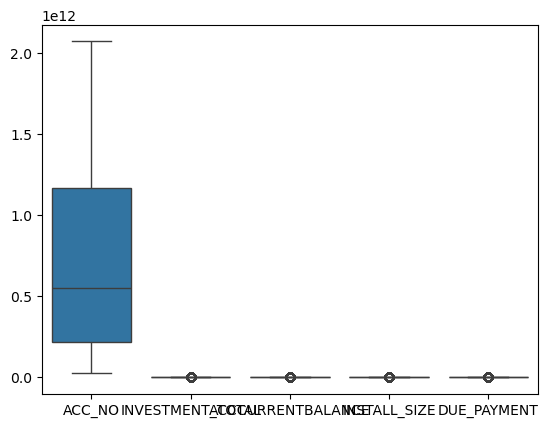

In [15]:
sns.boxplot(df)

In [16]:
df.head()


,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
0,27010017245,10720596,585913,M,F,0.0,0,N,Semi-urban,G,N
1,27010017436,43455000,585913,M,F,0.0,0,N,Semi-urban,G,N
2,27010017458,22012402,68348,M,F,0.0,2744483,N,Rural,G,N
3,27010017493,4893983,0,M,M,0.0,0,N,Semi-urban,G,N
4,27010017515,46254814,68348,M,F,0.0,0,N,Rural,G,N


In [17]:
df["INF_MARITAL_STATUS"].unique()

array(['M', 'U', 'O'], dtype=object)

In [18]:
df["COMPENSATION_CHARGED"].unique()

array(['N', 'Y'], dtype=object)

In [19]:
df["CLIENT_TYPE"].unique()

array(['Semi-urban', 'Rural', 'Urban', 0, 'Semi-Urban'], dtype=object)

In [20]:
df["QUALITY_OF_LOAN"].unique()

array(['G', 'B', 'SS', 'DF'], dtype=object)

In [21]:
df["REPAY_MODE"].unique()

array(['N', 'I'], dtype=object)

In [22]:
df['COMPENSATION_CHARGED'] = pd.get_dummies(df["COMPENSATION_CHARGED"],dtype=int,drop_first=True) #also we can give boolean
df['REPAY_MODE'] = pd.get_dummies(df['REPAY_MODE'],dtype=int,drop_first=True) #also we can give boolean

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['INF_MARITAL_STATUS'] = le.fit_transform(df['INF_MARITAL_STATUS'])

In [24]:
df["CLIENT_TYPE"] = df["CLIENT_TYPE"].astype(str)

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['CLIENT_TYPE'] = le.fit_transform(df['CLIENT_TYPE'])

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['INF_GENDER'] = le.fit_transform(df['INF_GENDER'])

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["QUALITY_OF_LOAN"] = le.fit_transform(df['QUALITY_OF_LOAN'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41718 entries, 0 to 4309
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ACC_NO                41718 non-null  int64  
 1   INVESTMENT_TOTAL      41718 non-null  int64  
 2   ACCCURRENTBALANCE     41718 non-null  int64  
 3   INF_MARITAL_STATUS    41718 non-null  int64  
 4   INF_GENDER            41718 non-null  int64  
 5   INSTALL_SIZE          41718 non-null  float64
 6   DUE_PAYMENT           41718 non-null  int64  
 7   COMPENSATION_CHARGED  41718 non-null  int64  
 8   CLIENT_TYPE           41718 non-null  int64  
 9   QUALITY_OF_LOAN       41718 non-null  int64  
 10  REPAY_MODE            41718 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 3.8 MB


In [29]:
corrmatrix=df.corr()
corrmatrix

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
ACC_NO,1.000000,-0.104074,-0.085316,0.015726,0.180033,-0.035755,-0.041368,-0.130771,-0.013380,0.139266,0.065350
INVESTMENT_TOTAL,-0.104074,1.000000,0.079319,-0.027508,-0.113378,-0.000005,0.284429,-0.011174,-0.017560,-0.007755,0.015716
ACCCURRENTBALANCE,-0.085316,0.079319,1.000000,-0.030049,-0.087988,-0.002410,0.032692,0.013942,-0.025148,0.017529,0.018407
INF_MARITAL_STATUS,0.015726,-0.027508,-0.030049,1.000000,0.116424,-0.004981,-0.011499,-0.011642,0.000260,0.015627,-0.008415
INF_GENDER,0.180033,-0.113378,-0.087988,0.116424,1.000000,-0.010118,-0.040209,0.027867,-0.062351,0.020230,0.035588
INSTALL_SIZE,-0.035755,-0.000005,-0.002410,-0.004981,-0.010118,1.000000,-0.002735,-0.016258,0.062280,0.008862,-0.150165
DUE_PAYMENT,-0.041368,0.284429,0.032692,-0.011499,-0.040209,-0.002735,1.000000,-0.004373,-0.010586,-0.001783,0.006964
COMPENSATION_CHARGED,-0.130771,-0.011174,0.013942,-0.011642,0.027867,-0.016258,-0.004373,1.000000,-0.057968,-0.162041,0.104485
CLIENT_TYPE,-0.013380,-0.017560,-0.025148,0.000260,-0.062351,0.062280,-0.010586,-0.057968,1.000000,0.084451,-0.398136
QUALITY_OF_LOAN,0.139266,-0.007755,0.017529,0.015627,0.020230,0.008862,-0.001783,-0.162041,0.084451,1.000000,-0.020586


<Axes: >

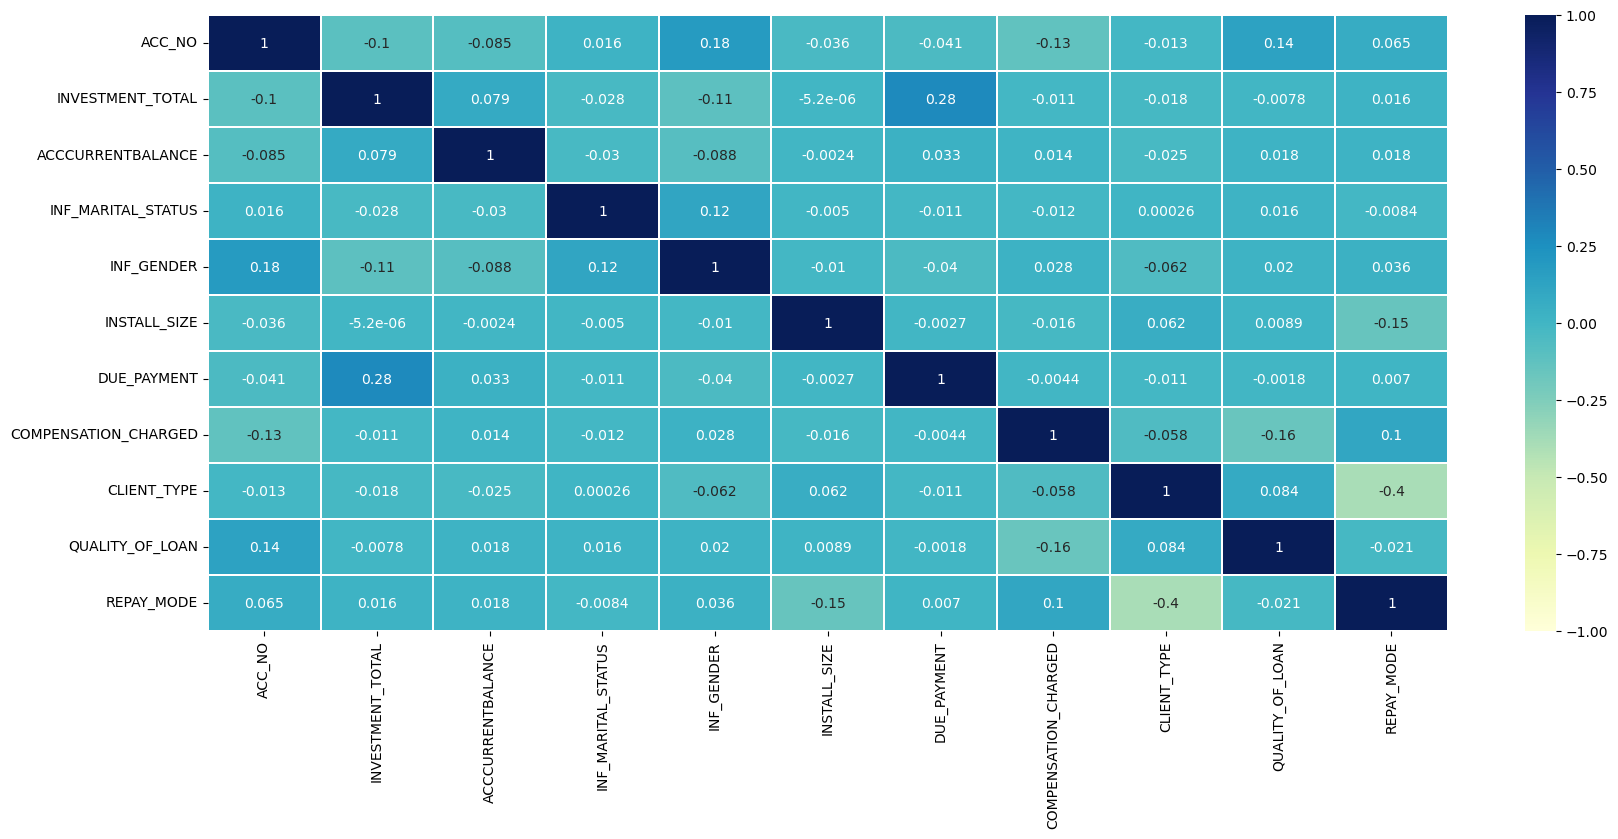

In [30]:
corrmatrix=df.corr()
#corrmatrix
plt.subplots(figsize=(20,8))
sns.heatmap(corrmatrix,vmin=-1,vmax=1,annot=True,linewidth=.2,cmap='YlGnBu')

In [31]:
x=df.drop('QUALITY_OF_LOAN',axis=1)
y=df['QUALITY_OF_LOAN']

In [32]:
x

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,REPAY_MODE
0,27010017245,10720596,585913,0,0,0.0,0,0,3,1
1,27010017436,43455000,585913,0,0,0.0,0,0,3,1
2,27010017458,22012402,68348,0,0,0.0,2744483,0,1,1
3,27010017493,4893983,0,0,1,0.0,0,0,3,1
4,27010017515,46254814,68348,0,0,0.0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...
4305,2068190000018,2711563,122498,0,1,0.0,0,0,1,1
4306,2068400000034,515411,41,0,1,0.0,19395,0,1,0
4307,2068400000045,541072,305,0,1,0.0,12546,0,1,0
4308,2068400000067,541232,0,0,1,0.0,12386,0,1,0


In [33]:
y

0       2
1       2
2       2
3       2
4       2
       ..
4305    2
4306    2
4307    2
4308    2
4309    2
Name: QUALITY_OF_LOAN, Length: 41718, dtype: int64

In [34]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
normalisation = MinMaxScaler()
x=normalisation.fit_transform(x)
# Coverting to Dataframe
x=pd.DataFrame(x)
x.describe()

,0,1,2,3,4,5,6,7,8,9
count,41718.000000,41718.000000,41718.000000,41718.000000,41718.000000,41718.000000,41718.000000,41718.000000,41718.000000,41718.000000
mean,0.330812,0.003533,0.005148,0.052999,0.376540,0.000695,0.000968,0.409727,0.415414,0.847236
std,0.277781,0.016551,0.027326,0.223605,0.215668,0.010454,0.011404,0.491789,0.265226,0.359764
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.093579,0.000205,0.000010,0.000000,0.500000,0.000000,0.000000,0.000000,0.250000,1.000000
50%,0.255246,0.000711,0.000104,0.000000,0.500000,0.000000,0.000000,0.000000,0.250000,1.000000
75%,0.558815,0.002451,0.001487,0.000000,0.500000,0.000000,0.000000,1.000000,0.750000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Model Building

In [35]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state =42,test_size=0.33)

In [36]:
x

,0,1,2,3,4,5,6,7,8,9
0,0.000000e+00,0.006774,2.694902e-03,0.0,0.0,0.0,0.000000,0.0,0.75,1.0
1,9.355958e-11,0.028468,2.694902e-03,0.0,0.0,0.0,0.000000,0.0,0.75,1.0
2,1.043361e-10,0.014257,3.143660e-04,0.0,0.0,0.0,0.007414,0.0,0.25,1.0
3,1.214805e-10,0.002912,0.000000e+00,0.0,0.5,0.0,0.000000,0.0,0.75,1.0
4,1.322570e-10,0.030323,3.143660e-04,0.0,0.0,0.0,0.000000,0.0,0.25,1.0
...,...,...,...,...,...,...,...,...,...,...
41713,9.998530e-01,0.001466,5.634285e-04,0.0,0.5,0.0,0.000000,0.0,0.25,1.0
41714,9.999559e-01,0.000010,1.885791e-07,0.0,0.5,0.0,0.000052,0.0,0.25,0.0
41715,9.999559e-01,0.000027,1.402845e-06,0.0,0.5,0.0,0.000034,0.0,0.25,0.0
41716,9.999559e-01,0.000027,0.000000e+00,0.0,0.5,0.0,0.000033,0.0,0.25,0.0


In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
log_model = LogisticRegression()

In [39]:
log_model.fit(x_train,y_train)

LogisticRegression()

In [40]:
y_pred = log_model.predict(x_test)

In [41]:
y_pred

array([2, 2, 2, ..., 2, 2, 2])

In [42]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [43]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.8964916103726303

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))  # Changed y_val to y_test to ensure consistent data sizes

Accuracy : 0.8964916103726303
Precision: 0.8036972074685118
Recall   : 0.8964916103726303
F1 Score : 0.8475621015909458

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1424
           2       0.90      1.00      0.95     12342
           3       0.00      0.00      0.00         1

    accuracy                           0.90     13767
   macro avg       0.30      0.33      0.32     13767
weighted avg       0.80      0.90      0.85     13767



In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [47]:
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [48]:
y_pred2 = rf.predict(x_test)

In [49]:
accuracy = accuracy_score(y_test,y_pred2)
accuracy

0.9400740902157333

In [50]:
print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred2, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred2, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred2))

Accuracy : 0.9400740902157333
Precision: 0.9353500901883491
Recall   : 0.9400740902157333
F1 Score : 0.935203192076748

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.56      0.66      1424
           2       0.95      0.98      0.97     12342
           3       0.00      0.00      0.00         1

    accuracy                           0.94     13767
   macro avg       0.58      0.51      0.54     13767
weighted avg       0.94      0.94      0.94     13767



In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred2, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred2, average='weighted'))

Accuracy : 0.9400740902157333
Precision: 0.9353500901883491
Recall   : 0.9400740902157333
F1 Score : 0.935203192076748


In [52]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    #scale_pos_weight=scale_pos_weight
)

xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
y_pred3 = xgb.predict(x_test)

In [54]:
print("Accuracy :", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred3, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred3, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred3))


Accuracy : 0.9254739594682937
Precision: 0.9212966045385893
Recall   : 0.9254739594682937
F1 Score : 0.91020516916809

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.33      0.48      1424
           2       0.93      0.99      0.96     12342
           3       0.00      0.00      0.00         1

    accuracy                           0.93     13767
   macro avg       0.60      0.44      0.48     13767
weighted avg       0.92      0.93      0.91     13767



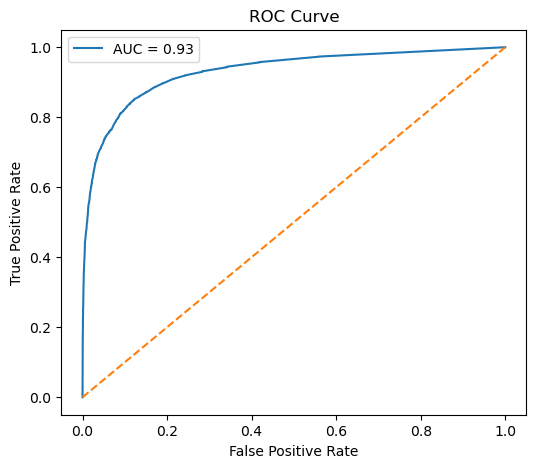

In [55]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert to binary (0 = risky)
y_val_bin = (y_test == 0).astype(int)

# Get probability for class 0
probs = rf.predict_proba(x_test)
class_index = list(rf.classes_).index(0)
y_prob = probs[:, class_index]

# ROC
fpr, tpr, thresholds = roc_curve(y_val_bin, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC-AUC score of 0.93 indicates that the model has excellent discrimination ability in separating risky and non-risky loan cases. Since the curve lies far above the diagonal reference line, the model performs significantly better than random guessing.

Three models were evaluated: Logistic Regression, Random Forest, and XGBoost. Logistic Regression failed to detect minority class instances due to class imbalance. XGBoost showed moderate improvement but still struggled with recall for risky customers. Random Forest achieved the best balance between precision and recall, especially improving detection of high-risk customers. Therefore, Random Forest was selected as the final model.

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# If X_train is not a DataFrame, rebuild it with column names from X
if not isinstance(x_train, pd.DataFrame):
    x_train = pd.DataFrame(x_train, columns=x.columns)

if not isinstance(x_test, pd.DataFrame):
    x_test = pd.DataFrame(x_test, columns=x.columns)

# Feature importance
feature_importance = pd.Series(rf.feature_importances_, index=x_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# Print top 10
print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
0    0.369257
1    0.235454
2    0.199368
7    0.064352
6    0.046074
5    0.038885
8    0.022562
4    0.012366
3    0.005919
9    0.005763
dtype: float64


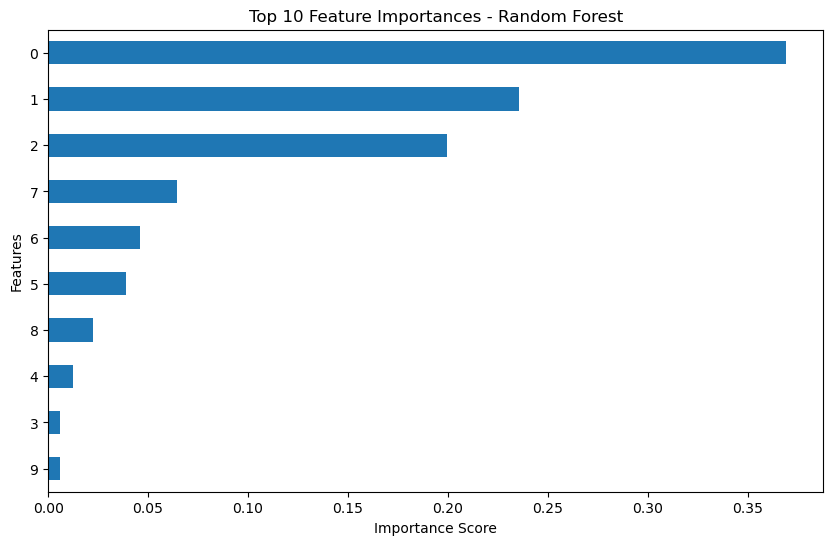

In [57]:
plt.figure(figsize=(10,6))
feature_importance.head(10).sort_values().plot(kind='barh')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

In [58]:
!pip install shap

In [59]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_test)


In [ ]:
print("Classes in model:", rf.classes_)

In [ ]:
import pandas as pd
import shap

# Ensure DataFrame format with correct feature names
if not isinstance(x_test, pd.DataFrame):
    x_test = pd.DataFrame(x_test, columns=x_train.columns)

if not isinstance(x_test, pd.DataFrame):
    x_test = pd.DataFrame(x_test, columns=x_train.columns)

# Convert column names to strings
x_test.columns = x_test.columns.astype(str)

# SHAP explainer
explainer = shap.TreeExplainer(rf)

# SHAP values for validation set
shap_values_test = explainer.shap_values(x_test)

# Summary plot for class 0
shap.summary_plot(shap_values_test[0], x_test)  # Changed shap_values_val to shap_values_test

# Bar plot
shap.summary_plot(shap_values_test[0], x_test, plot_type="bar")